In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
print("Eager execution enabled:", tf.executing_eagerly())
import random

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

import datetime
from check_stationarity import load_train_data

Eager execution enabled: True


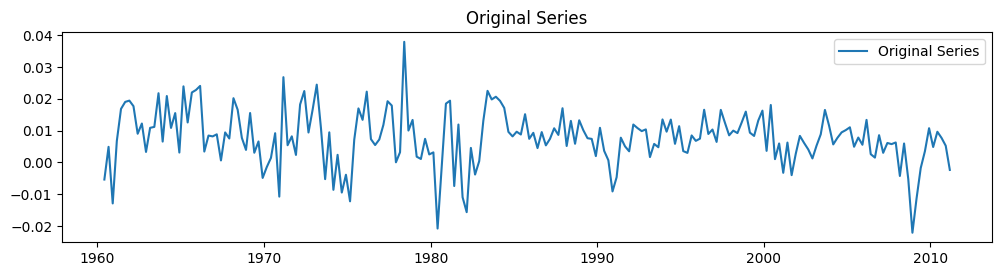

In [2]:

# Set the random seed for reproducibility
seed = 256
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# train_md, train_qd = load_train_data()
_, train_data_univariate = load_train_data()
train_data_univariate = train_data_univariate["GDPC1"]

# Plot the original and transformed series
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(train_data_univariate, label="Original Series")
plt.title("Original Series")
plt.legend()



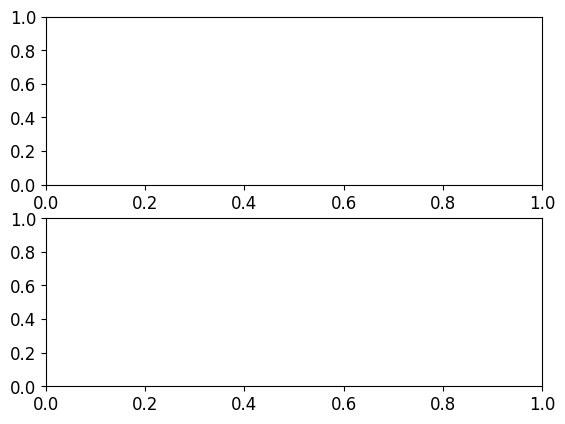

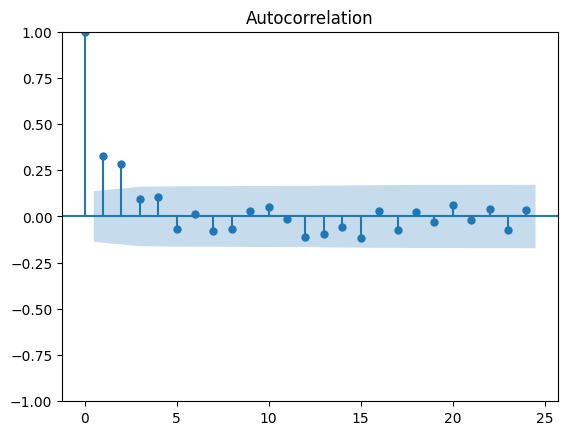

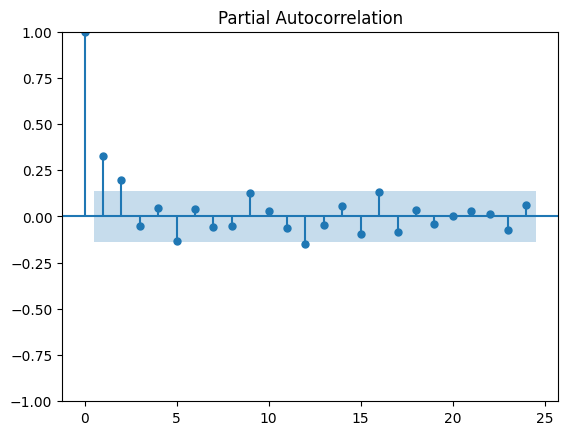

In [3]:
import matplotlib
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ax1 = plt.subplot(211)
ax2 = plt.subplot(212)

# Plot acf and pacf 
plot_acf(train_data_univariate)
plot_pacf(train_data_univariate, method="ywm")
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()


The blue regions the points are no longer statistically significant and from the plot we see the last lag that is statistically significant for autocorrelation plot ~2 and partial autocorrelation ~9

c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-DEC will be used.
  self._init_dates(dates, freq)
c:\Users\giada\Documents\GDP nowcasting thesis\thesis-env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive

RMSE: 0.00667606604884297


C:\Users\giada\AppData\Local\Temp\ipykernel_20380\163422294.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model.forecast(steps=1)[0]


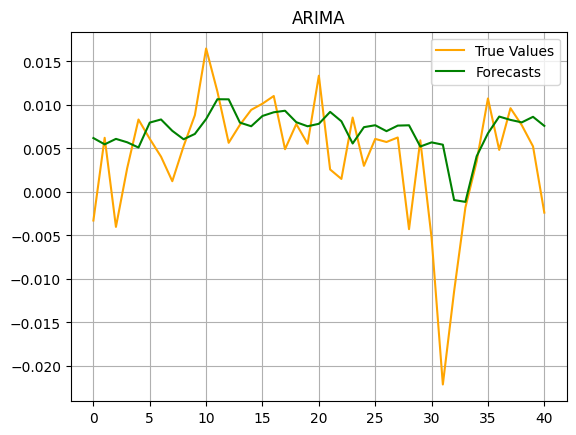

history: [-0.0032833724491432, 0.0062256099147717, -0.0040144390418177, 0.0027439863023577, 0.0083288055688957, 0.00610837169347, 0.0040568740473787, 0.0012352872439738, 0.0052526007658499, 0.0088172304528679, 0.0164952025859435, 0.0115403670474024, 0.0056505202389018, 0.0077196499189415, 0.0094412298851711, 0.0101503913211332, 0.0110325505292366, 0.0049141503086236, 0.0078075817011313, 0.0055397923720761, 0.013364138447713, 0.0025841857488995, 0.0014984360400802, 0.008557775565416, 0.0030038406171311, 0.0060989829146809, 0.0057437311093071, 0.0062627155121948, -0.0042767755900321, 0.0059366259313158, -0.0052664238027837, -0.0221334127394854, -0.0114136313599023, -0.001788107217628, 0.0035057715471396, 0.0107511353792447, 0.004833310220679, 0.0096293498226085, 0.0076812727050032, 0.0052373636444507, -0.0023748667360497]
forecasts: [np.float64(0.006196647305981834), np.float64(0.005473979666897692), np.float64(0.006101231458907123), np.float64(0.005710058820027867), np.float64(0.0051064

In [4]:
# Split train and val sets 

train = train_data_univariate[:int(len(train_data_univariate) * 0.8)]
val = train_data_univariate[int(len(train_data_univariate) * 0.8):]

# Build ARIMA model
model = ARIMA(train, order=(2, 0, 2)).fit()

forecasts = []

# Copy the training data to use for recursive forecasting
history = []  # Convert to a list for appending new values

# Recursive forecasting
for true_value in val:
    
    # print("forecast:", model.forecast(steps=1))

    forecast = model.forecast(steps=1)[0]
    forecasts.append(forecast)
  
    model = model.append([true_value], refit=False)
    
    # Append the true value to the history for the next iteration
    history.append(true_value)


print("RMSE:", root_mean_squared_error(forecasts, history))

plt.plot(history, label="True Values", color="orange")
plt.plot(forecasts, label="Forecasts", color="green")
plt.title("ARIMA")
plt.legend()
plt.grid()

plt.show()

print("history:", history)
print("forecasts:", forecasts)

# boxcox_diff_pred = model.forecast(len(val))
# # Inverse Box-Cox transformation
# forecast = inv_boxcox(boxcox_diff_pred, lambda_boxcox)




ARIMA Grid Search:
ARIMA(1, 0, 1) - AIC: -1090.2612277972657
ARIMA(1, 0, 2) - AIC: -1090.345734306984
ARIMA(1, 0, 3) - AIC: -1087.9871374390236
ARIMA(1, 0, 4) - AIC: -1089.3642017563493
ARIMA(1, 0, 5) - AIC: -1087.3619626293234
ARIMA(1, 0, 6) - AIC: -1085.6141666741778
ARIMA(1, 0, 7) - AIC: -1092.6198709906803
ARIMA(1, 0, 8) - AIC: -1092.847419836577
ARIMA(2, 0, 1) - AIC: -1092.091783382712
ARIMA(2, 0, 2) - AIC: -1088.4212845906854
ARIMA(2, 0, 3) - AIC: -1088.520344872943
ARIMA(2, 0, 4) - AIC: -1088.7803886692677
ARIMA(2, 0, 5) - AIC: -1084.7160568093718
ARIMA(2, 0, 6) - AIC: -1083.0420022304286
ARIMA(2, 0, 7) - AIC: -1092.9721151558851
ARIMA(2, 0, 8) - AIC: -1090.4217433675744
ARIMA(3, 0, 1) - AIC: -1089.021391735434
ARIMA(3, 0, 2) - AIC: -1086.3813548916632
ARIMA(3, 0, 3) - AIC: -1087.5771817504542
ARIMA(3, 0, 4) - AIC: -1086.9560702646563
ARIMA(3, 0, 5) - AIC: -1088.3070662500868
ARIMA(3, 0, 6) - AIC: -1084.8315025541178
ARIMA(3, 0, 7) - AIC: -1090.7822414903385
ARIMA(3, 0, 8) - AIC

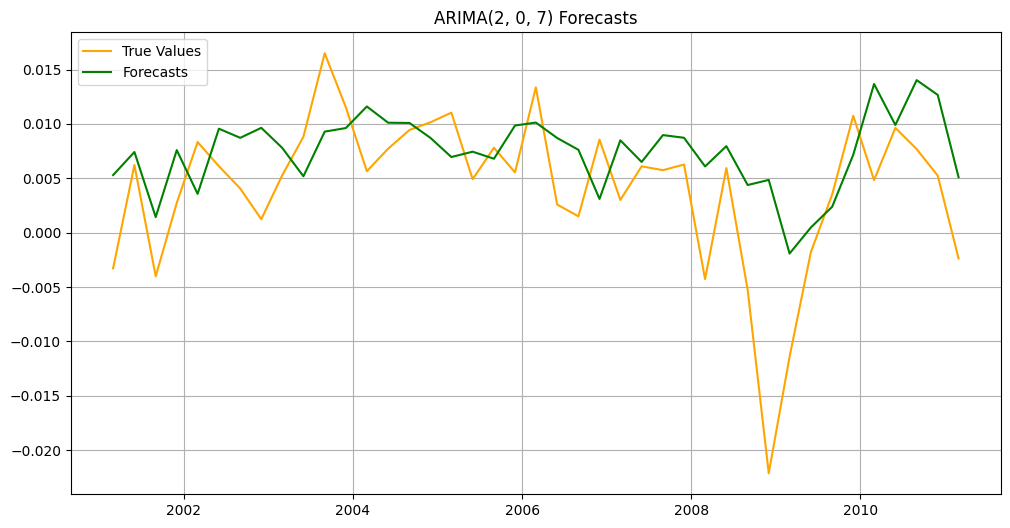

In [7]:
import itertools
import warnings

# Grid search for ARIMA model parameters
warnings.filterwarnings('ignore')

# Define parameter ranges
p = range(1, 9)
d = range(0, 1)
q = range(1, 9)
pdq = list(itertools.product(p, d, q))

# Initialize variables to track best model
best_aic = float("inf")
best_pdq = None
best_model = None

# Perform grid search
print("ARIMA Grid Search:")
print("=================")
for param in pdq:
    try:
        model = ARIMA(train, order=param)
        results = model.fit()
        aic = results.aic
        print(f"ARIMA{param} - AIC: {aic}")
        
        if aic < best_aic:
            best_aic = aic
            best_pdq = param
            best_model = results
    except Exception as e:
        continue

print("\nBest ARIMA model:")
print(f"ARIMA{best_pdq} - AIC: {best_aic}")

# Generate forecasts with the best model
forecasts = []
model = best_model

for true_value in val:
    forecast = model.forecast(steps=1)[0]
    forecasts.append(forecast)
    model = model.append([true_value], refit=False)

print("\nRMSE with best model:", root_mean_squared_error(val, forecasts))

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(val.index, val, label="True Values", color="orange")
plt.plot(val.index, forecasts, label="Forecasts", color="green")
plt.title(f"ARIMA{best_pdq} Forecasts")
plt.legend()
plt.grid()
plt.show()

In [6]:
import plotly.graph_objects as go

def plot_forecasts(train: pd.DataFrame, val: pd.DataFrame, forecasts: list, title: str) -> None:
    """
    Function to plot the forecasts for GDP data.
    
    Parameters:
    - train: DataFrame containing the training data with a 'Date' column and 'GDP' column.
    - test: DataFrame containing the test data with a 'Date' column and 'GDP' column.
    - forecasts: List of forecasted values corresponding to the test data.
    - title: Title of the plot.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot training data
    # plt.plot(train.index, inv_boxcox(train['GDPC1'], lambda_boxcox), label='Train', color='blue')
    
    # Plot validation data
    plt.plot(val.index, inv_boxcox(val['GDPC1'], lambda_boxcox), label='Val', color='orange')
    
    # Plot forecast data
    plt.plot(val.index, forecasts, label='Forecast', color='green')
    
    # Add title and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('GDP', fontsize=14)
    
    # Add legend
    plt.legend(fontsize=12)
    
    # Show grid
    plt.grid(True)
    
    # Display the plot
    plt.show()

# Example usage
# Assuming `train`, `test`, and `forecasts` are already defined
# train: DataFrame with 'Date' and 'GDP' columns for training data
# test: DataFrame with 'Date' and 'GDP' columns for test data
# forecasts: List of forecasted GDP values
plot_forecasts(train, val, forecasts, 'ARIMA GDP Nowcasting')
mse = mean_squared_error(inv_boxcox(val['GDPC1'], lambda_boxcox), forecasts)
print("Mean Squared Error:", mse)


NameError: name 'inv_boxcox' is not defined

<Figure size 1200x600 with 0 Axes>